In [2]:
!pip install lifelines

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4137 sha256=21ac83d4c17ef4bc9d9fdd899a2efd414bcda75d26d3c7307c1d9f029c89ba58
  Stored in directory: c:\users\fafure j\appdata\local\pip\cache\wheels\7e\16\46\9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# Stats
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

STAGE_ORDER  = ['I', 'II', 'III', 'IV']
STAGE_COLORS = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

print('✅ All libraries loaded')

✅ All libraries loaded


In [4]:
df = pd.read_csv(r"C:\Users\Fafure J\Documents\Joan 499 Project\colorectal_cancer_prediction.csv")
print(f'Shape: {df.shape}')

# Create numeric event columns
df['Event_Recurrence'] = (df['Recurrence'] == 'Yes').astype(int)      # 1 = recurrence happened
df['Event_Deceased']   = (df['Survival_Status'] == 'Deceased').astype(int)  # 1 = deceased
df['Duration']         = df['Time_to_Recurrence']  # months of follow-up

# Stage severity for ordering
df['Stage_Num'] = df['Stage_at_Diagnosis'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})

print(f'\nFollow-up duration: {df["Duration"].min()} – {df["Duration"].max()} months')
print(f'Overall recurrence rate : {df["Event_Recurrence"].mean()*100:.1f}%')
print(f'Overall mortality rate  : {df["Event_Deceased"].mean()*100:.1f}%')
df[['Duration', 'Recurrence', 'Survival_Status', 'Stage_at_Diagnosis']].head()

Shape: (89945, 30)

Follow-up duration: 0 – 59 months
Overall recurrence rate : 30.0%
Overall mortality rate  : 25.1%


,Duration,Recurrence,Survival_Status,Stage_at_Diagnosis
0,16,No,Survived,III
1,28,No,Deceased,I
2,26,No,Survived,III
3,44,No,Deceased,I
4,20,Yes,Deceased,III


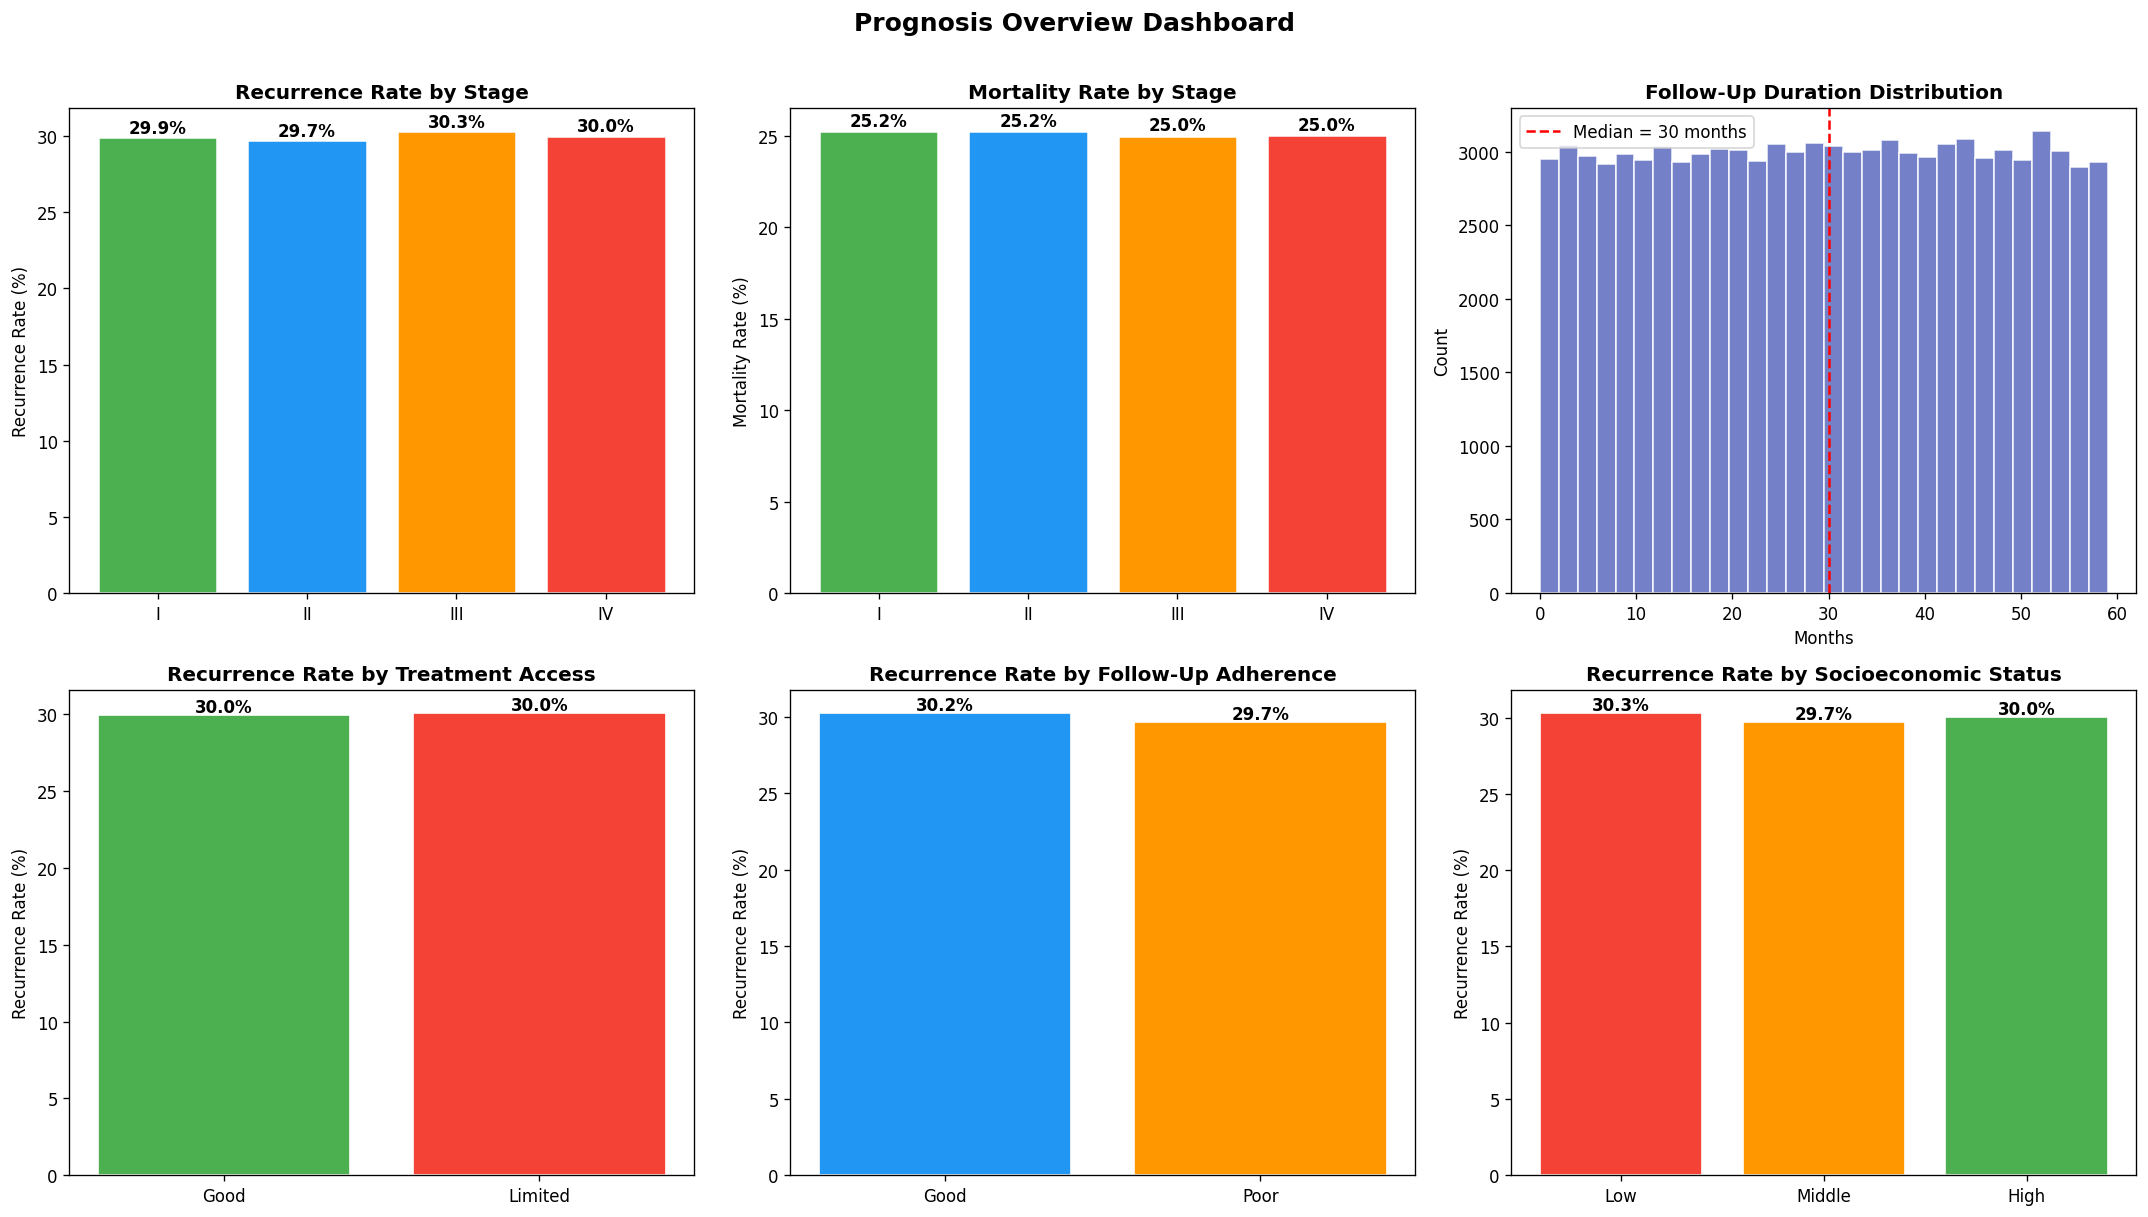

In [5]:
# --- Overview dashboard ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Recurrence rate by stage
rec_stage = df.groupby('Stage_at_Diagnosis')['Event_Recurrence'].mean() * 100
rec_stage = rec_stage.reindex(STAGE_ORDER)
axes[0].bar(rec_stage.index, rec_stage.values, color=STAGE_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Recurrence Rate by Stage', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Recurrence Rate (%)')
for i, v in enumerate(rec_stage.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Mortality rate by stage
mort_stage = df.groupby('Stage_at_Diagnosis')['Event_Deceased'].mean() * 100
mort_stage = mort_stage.reindex(STAGE_ORDER)
axes[1].bar(mort_stage.index, mort_stage.values, color=STAGE_COLORS, edgecolor='white', linewidth=1.5)
axes[1].set_title('Mortality Rate by Stage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mortality Rate (%)')
for i, v in enumerate(mort_stage.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Follow-up duration distribution
axes[2].hist(df['Duration'], bins=30, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[2].set_title('Follow-Up Duration Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Months'); axes[2].set_ylabel('Count')
axes[2].axvline(df['Duration'].median(), color='red', linestyle='--',
                label=f'Median = {df["Duration"].median():.0f} months')
axes[2].legend()

# 4. Recurrence by treatment access
ct = df.groupby('Treatment_Access')['Event_Recurrence'].mean() * 100
axes[3].bar(ct.index, ct.values, color=['#4CAF50', '#F44336'], edgecolor='white')
axes[3].set_title('Recurrence Rate by Treatment Access', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Recurrence Rate (%)')
for i, v in enumerate(ct.values):
    axes[3].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# 5. Recurrence by follow-up adherence
ct2 = df.groupby('Follow_Up_Adherence')['Event_Recurrence'].mean() * 100
axes[4].bar(ct2.index, ct2.values, color=['#2196F3', '#FF9800'], edgecolor='white')
axes[4].set_title('Recurrence Rate by Follow-Up Adherence', fontsize=12, fontweight='bold')
axes[4].set_ylabel('Recurrence Rate (%)')
for i, v in enumerate(ct2.values):
    axes[4].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. Recurrence by socioeconomic status
ct3 = df.groupby('Socioeconomic_Status')['Event_Recurrence'].mean() * 100
ct3 = ct3.reindex(['Low', 'Middle', 'High'])
axes[5].bar(ct3.index, ct3.values, color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='white')
axes[5].set_title('Recurrence Rate by Socioeconomic Status', fontsize=12, fontweight='bold')
axes[5].set_ylabel('Recurrence Rate (%)')
for i, v in enumerate(ct3.values):
    axes[5].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Prognosis Overview Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nb3_fig1_overview.png', bbox_inches='tight')
plt.show()

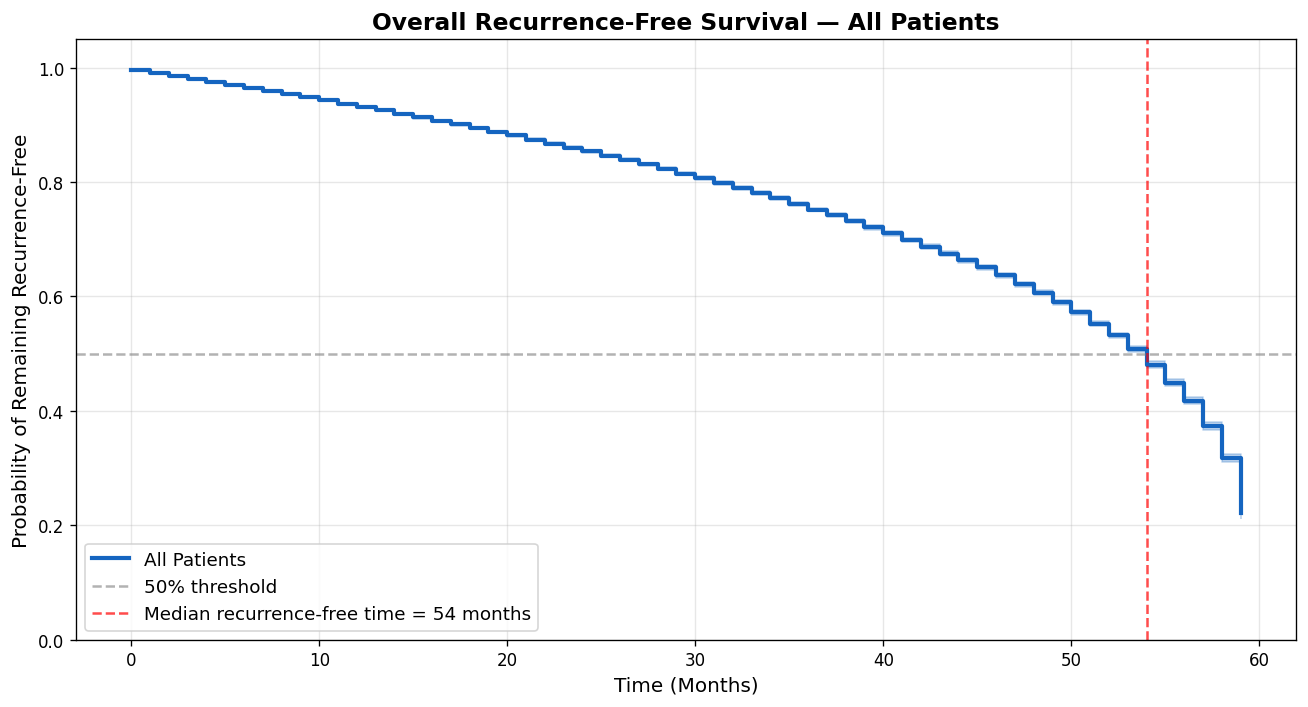

Median recurrence-free survival time: 54.0 months
At 12 months: 93.1% of patients remain recurrence-free
At 24 months: 85.4% of patients remain recurrence-free
At 48 months: 60.6% of patients remain recurrence-free


In [6]:
# === KM Curve 1: Overall Recurrence-Free Survival ===
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(11, 6))
kmf.fit(df['Duration'], event_observed=df['Event_Recurrence'], label='All Patients')
kmf.plot_survival_function(ax=ax, ci_show=True, color='#1565C0', linewidth=2.5)

median_rfs = kmf.median_survival_time_
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label=f'50% threshold')
ax.axvline(median_rfs, color='red', linestyle='--', alpha=0.7,
           label=f'Median recurrence-free time = {median_rfs:.0f} months')

ax.set_title('Overall Recurrence-Free Survival — All Patients', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('nb3_fig2_km_overall.png', bbox_inches='tight')
plt.show()

print(f'Median recurrence-free survival time: {median_rfs:.1f} months')
print(f'At 12 months: {kmf.predict(12)*100:.1f}% of patients remain recurrence-free')
print(f'At 24 months: {kmf.predict(24)*100:.1f}% of patients remain recurrence-free')
print(f'At 48 months: {kmf.predict(48)*100:.1f}% of patients remain recurrence-free')

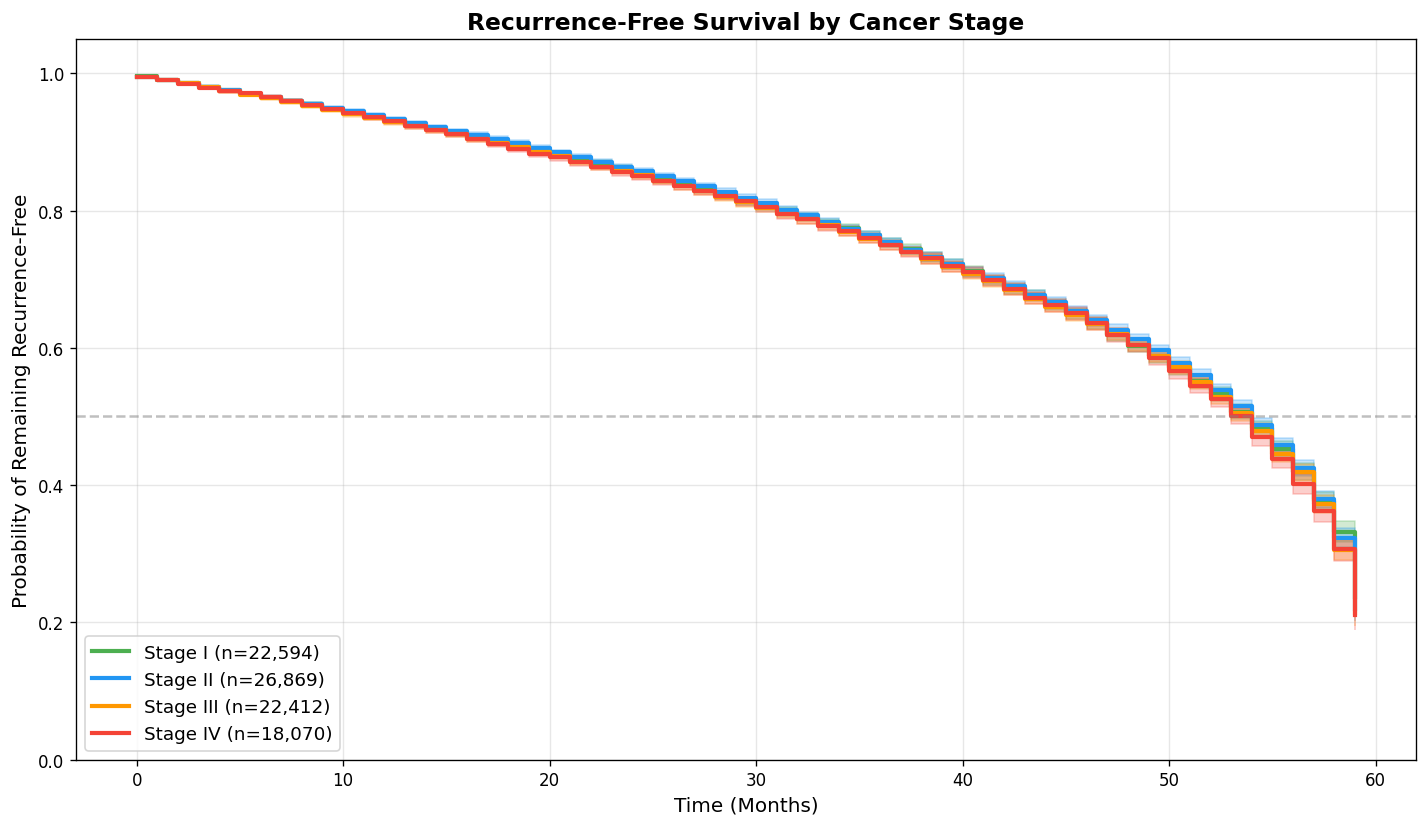

In [7]:
# === KM Curve 2: Recurrence-Free Survival by Stage ===
fig, ax = plt.subplots(figsize=(12, 7))
kmf = KaplanMeierFitter()

for stage, color in zip(STAGE_ORDER, STAGE_COLORS):
    mask = df['Stage_at_Diagnosis'] == stage
    kmf.fit(df.loc[mask, 'Duration'],
            event_observed=df.loc[mask, 'Event_Recurrence'],
            label=f'Stage {stage} (n={mask.sum():,})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2.5)

ax.set_title('Recurrence-Free Survival by Cancer Stage', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nb3_fig3_km_by_stage.png', bbox_inches='tight')
plt.show()

In [8]:
# === Log-Rank Test: Stage ===
# Tests whether the survival curves between stages are statistically different
results = multivariate_logrank_test(
    df['Duration'], df['Stage_at_Diagnosis'], df['Event_Recurrence']
)
print('=== Log-Rank Test: Recurrence by Stage ===')
print(f'Test Statistic : {results.test_statistic:.4f}')
print(f'p-value        : {results.p_value:.6f}')
if results.p_value < 0.05:
    print('✅ SIGNIFICANT — Stage groups have statistically different recurrence-free survival (p < 0.05)')
else:
    print('❌ NOT SIGNIFICANT — No significant difference between stage groups')

=== Log-Rank Test: Recurrence by Stage ===
Test Statistic : 5.7322
p-value        : 0.125392
❌ NOT SIGNIFICANT — No significant difference between stage groups


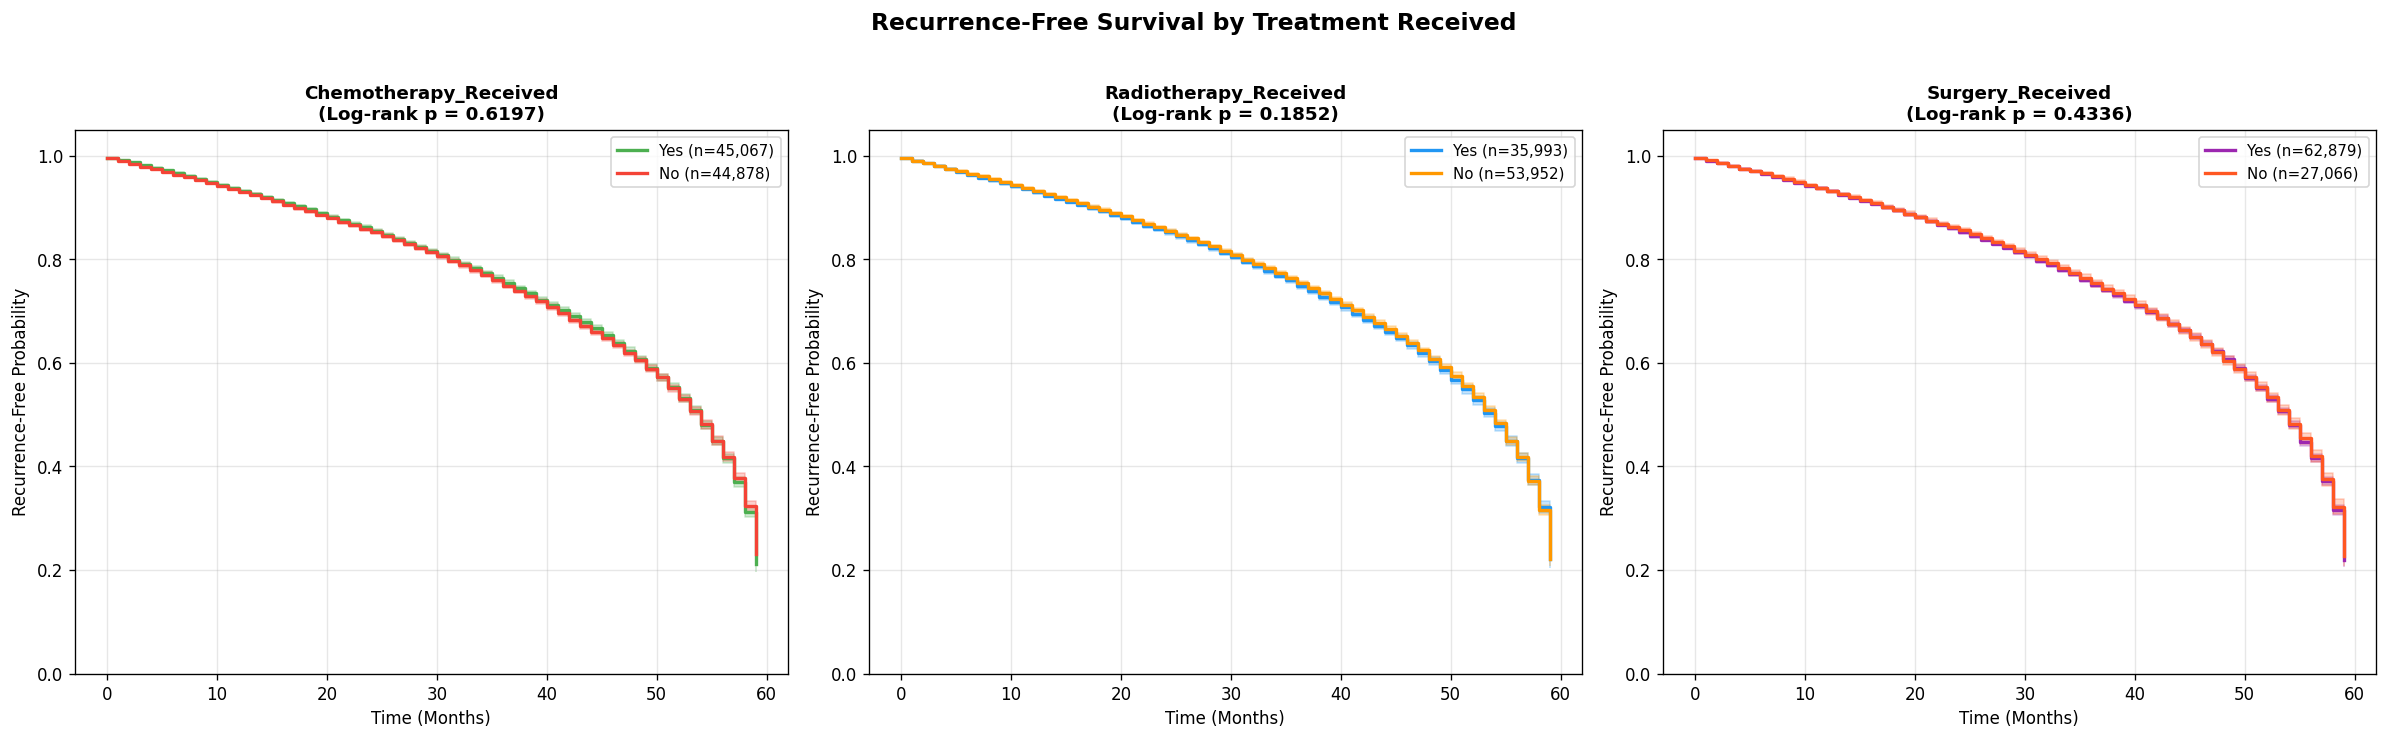

In [9]:
# === KM Curve 3: by Treatment Received ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
treatment_cols = ['Chemotherapy_Received', 'Radiotherapy_Received', 'Surgery_Received']
treat_colors   = [('#4CAF50', '#F44336'), ('#2196F3', '#FF9800'), ('#9C27B0', '#FF5722')]

for i, (col, colors) in enumerate(zip(treatment_cols, treat_colors)):
    kmf = KaplanMeierFitter()
    for val, color in zip(['Yes', 'No'], colors):
        mask = df[col] == val
        kmf.fit(df.loc[mask, 'Duration'],
                event_observed=df.loc[mask, 'Event_Recurrence'],
                label=f'{val} (n={mask.sum():,})')
        kmf.plot_survival_function(ax=axes[i], ci_show=True, color=color, linewidth=2)

    # Log-rank p-value
    g1 = df[df[col] == 'Yes']
    g2 = df[df[col] == 'No']
    lr = logrank_test(g1['Duration'], g2['Duration'],
                      g1['Event_Recurrence'], g2['Event_Recurrence'])

    axes[i].set_title(f'{col}\n(Log-rank p = {lr.p_value:.4f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Time (Months)')
    axes[i].set_ylabel('Recurrence-Free Probability')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0, 1.05)

plt.suptitle('Recurrence-Free Survival by Treatment Received', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nb3_fig4_km_by_treatment.png', bbox_inches='tight')
plt.show()

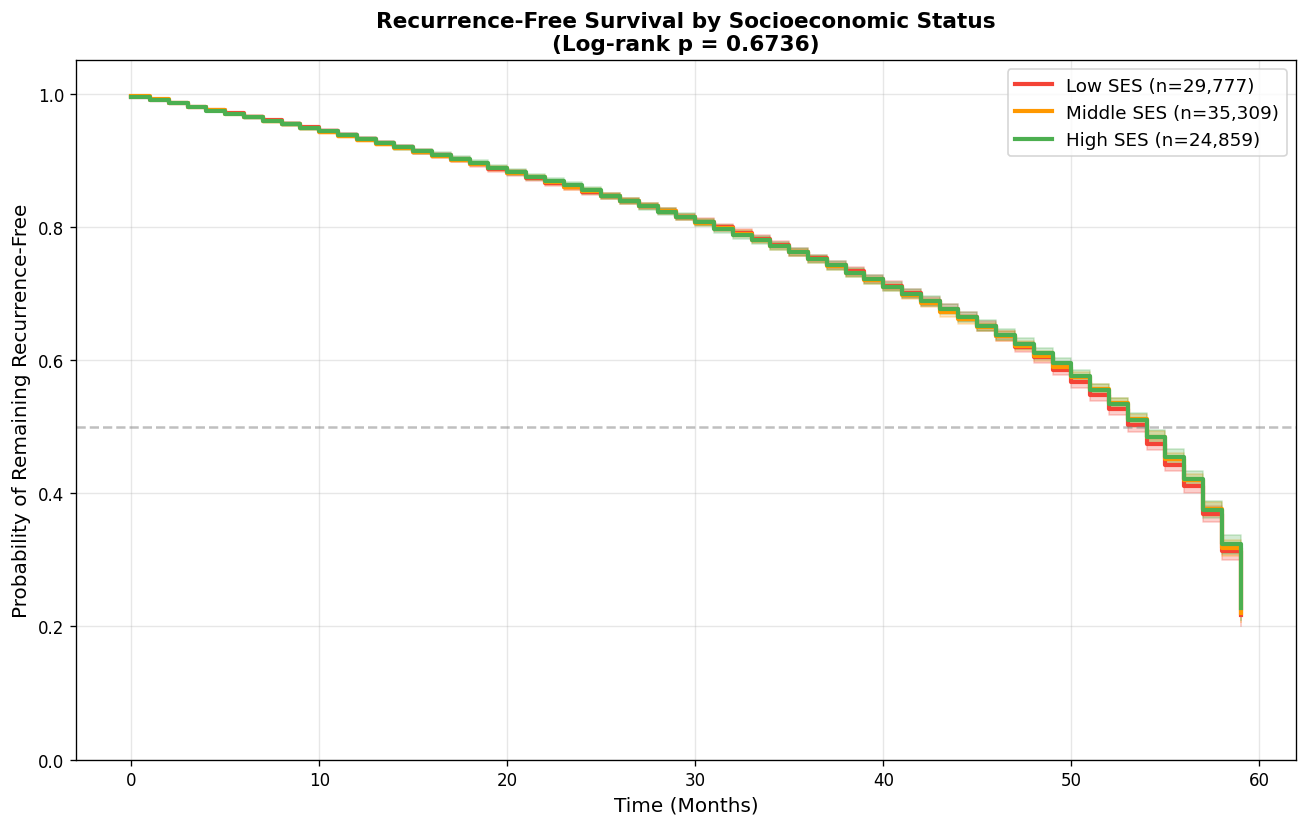

In [10]:
# === KM Curve 4: by Socioeconomic Status ===
fig, ax = plt.subplots(figsize=(11, 7))
kmf = KaplanMeierFitter()
ses_groups = ['Low', 'Middle', 'High']
ses_colors = ['#F44336', '#FF9800', '#4CAF50']

for ses, color in zip(ses_groups, ses_colors):
    mask = df['Socioeconomic_Status'] == ses
    kmf.fit(df.loc[mask, 'Duration'],
            event_observed=df.loc[mask, 'Event_Recurrence'],
            label=f'{ses} SES (n={mask.sum():,})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2.5)

lr_ses = multivariate_logrank_test(
    df['Duration'], df['Socioeconomic_Status'], df['Event_Recurrence']
)

ax.set_title(f'Recurrence-Free Survival by Socioeconomic Status\n(Log-rank p = {lr_ses.p_value:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nb3_fig5_km_by_ses.png', bbox_inches='tight')
plt.show()

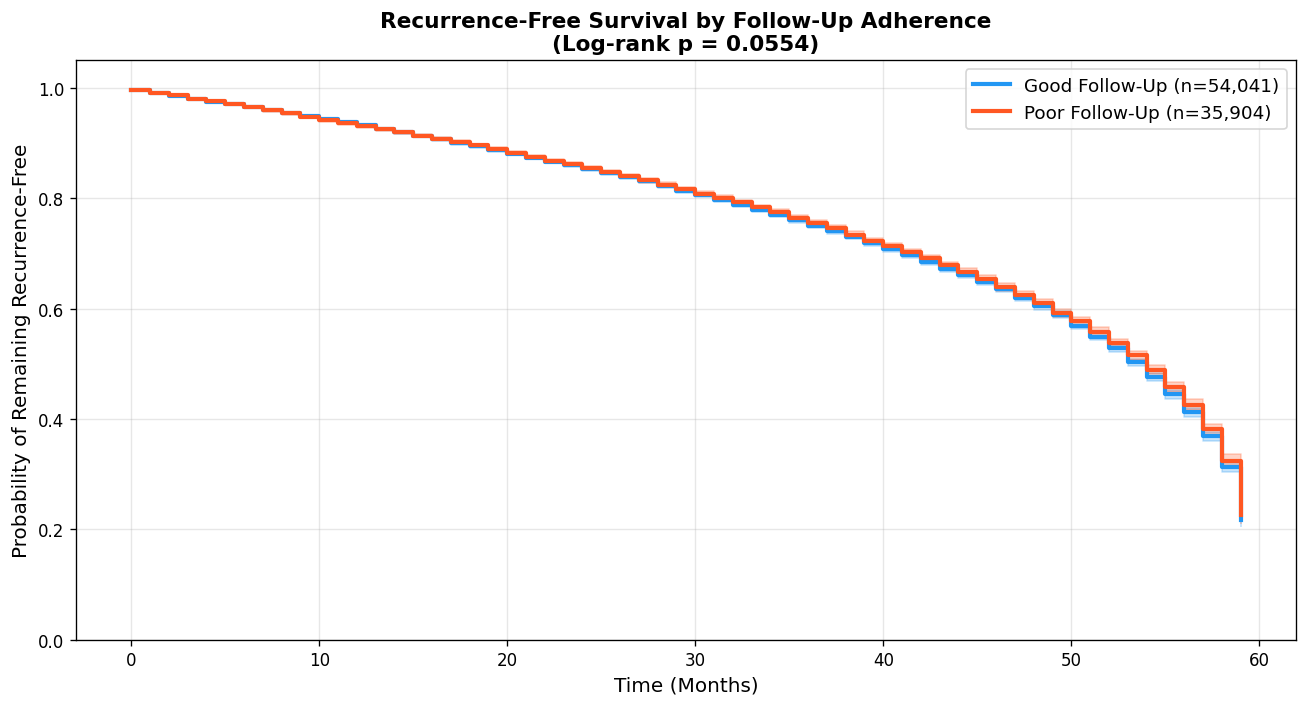

In [11]:
# === KM Curve 5: by Follow-Up Adherence ===
fig, ax = plt.subplots(figsize=(11, 6))
kmf = KaplanMeierFitter()

for val, color in zip(['Good', 'Poor'], ['#2196F3', '#FF5722']):
    mask = df['Follow_Up_Adherence'] == val
    kmf.fit(df.loc[mask, 'Duration'],
            event_observed=df.loc[mask, 'Event_Recurrence'],
            label=f'{val} Follow-Up (n={mask.sum():,})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2.5)

g1 = df[df['Follow_Up_Adherence'] == 'Good']
g2 = df[df['Follow_Up_Adherence'] == 'Poor']
lr_fu = logrank_test(g1['Duration'], g2['Duration'], g1['Event_Recurrence'], g2['Event_Recurrence'])

ax.set_title(f'Recurrence-Free Survival by Follow-Up Adherence\n(Log-rank p = {lr_fu.p_value:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('nb3_fig6_km_followup.png', bbox_inches='tight')
plt.show()

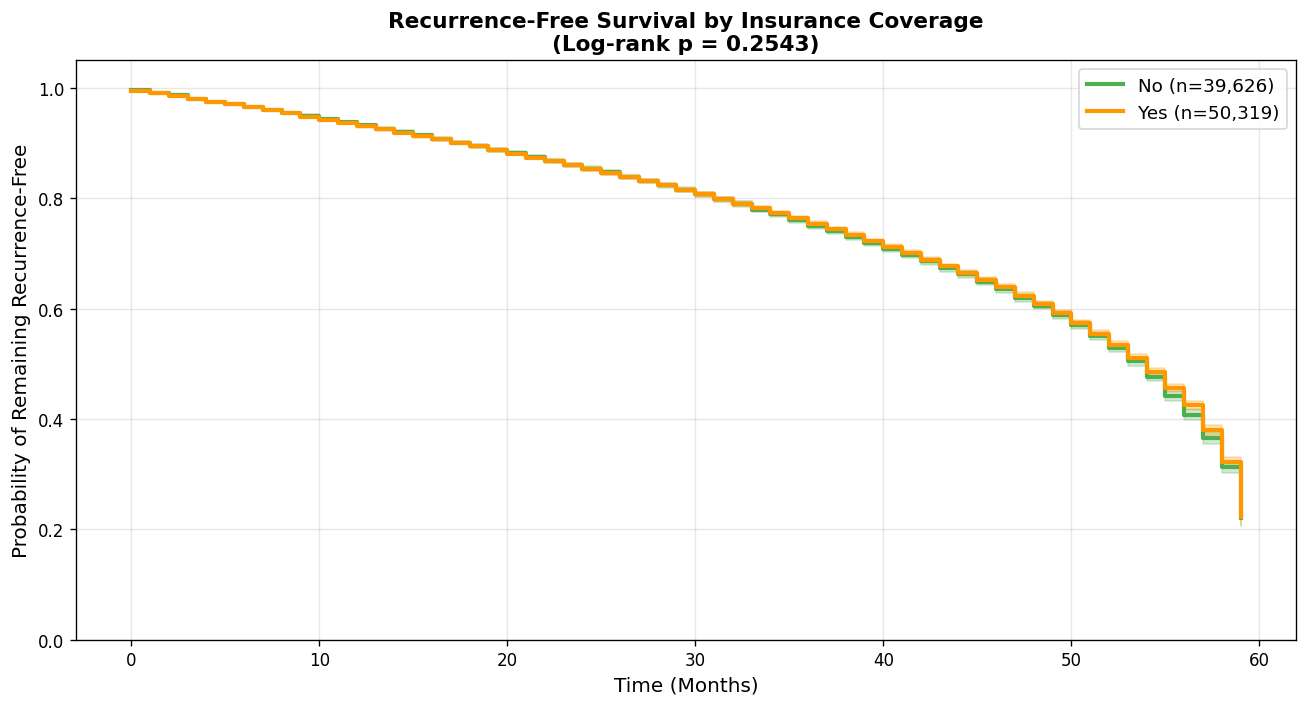

In [12]:
# === KM Curve 6: by Insurance Coverage ===
fig, ax = plt.subplots(figsize=(11, 6))
kmf = KaplanMeierFitter()
ins_groups = df['Insurance_Coverage'].unique()
ins_colors = ['#4CAF50', '#FF9800', '#F44336'][:len(ins_groups)]

for ins, color in zip(sorted(ins_groups), ins_colors):
    mask = df['Insurance_Coverage'] == ins
    kmf.fit(df.loc[mask, 'Duration'],
            event_observed=df.loc[mask, 'Event_Recurrence'],
            label=f'{ins} (n={mask.sum():,})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2.5)

lr_ins = multivariate_logrank_test(
    df['Duration'], df['Insurance_Coverage'], df['Event_Recurrence']
)

ax.set_title(f'Recurrence-Free Survival by Insurance Coverage\n(Log-rank p = {lr_ins.p_value:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('nb3_fig7_km_insurance.png', bbox_inches='tight')
plt.show()

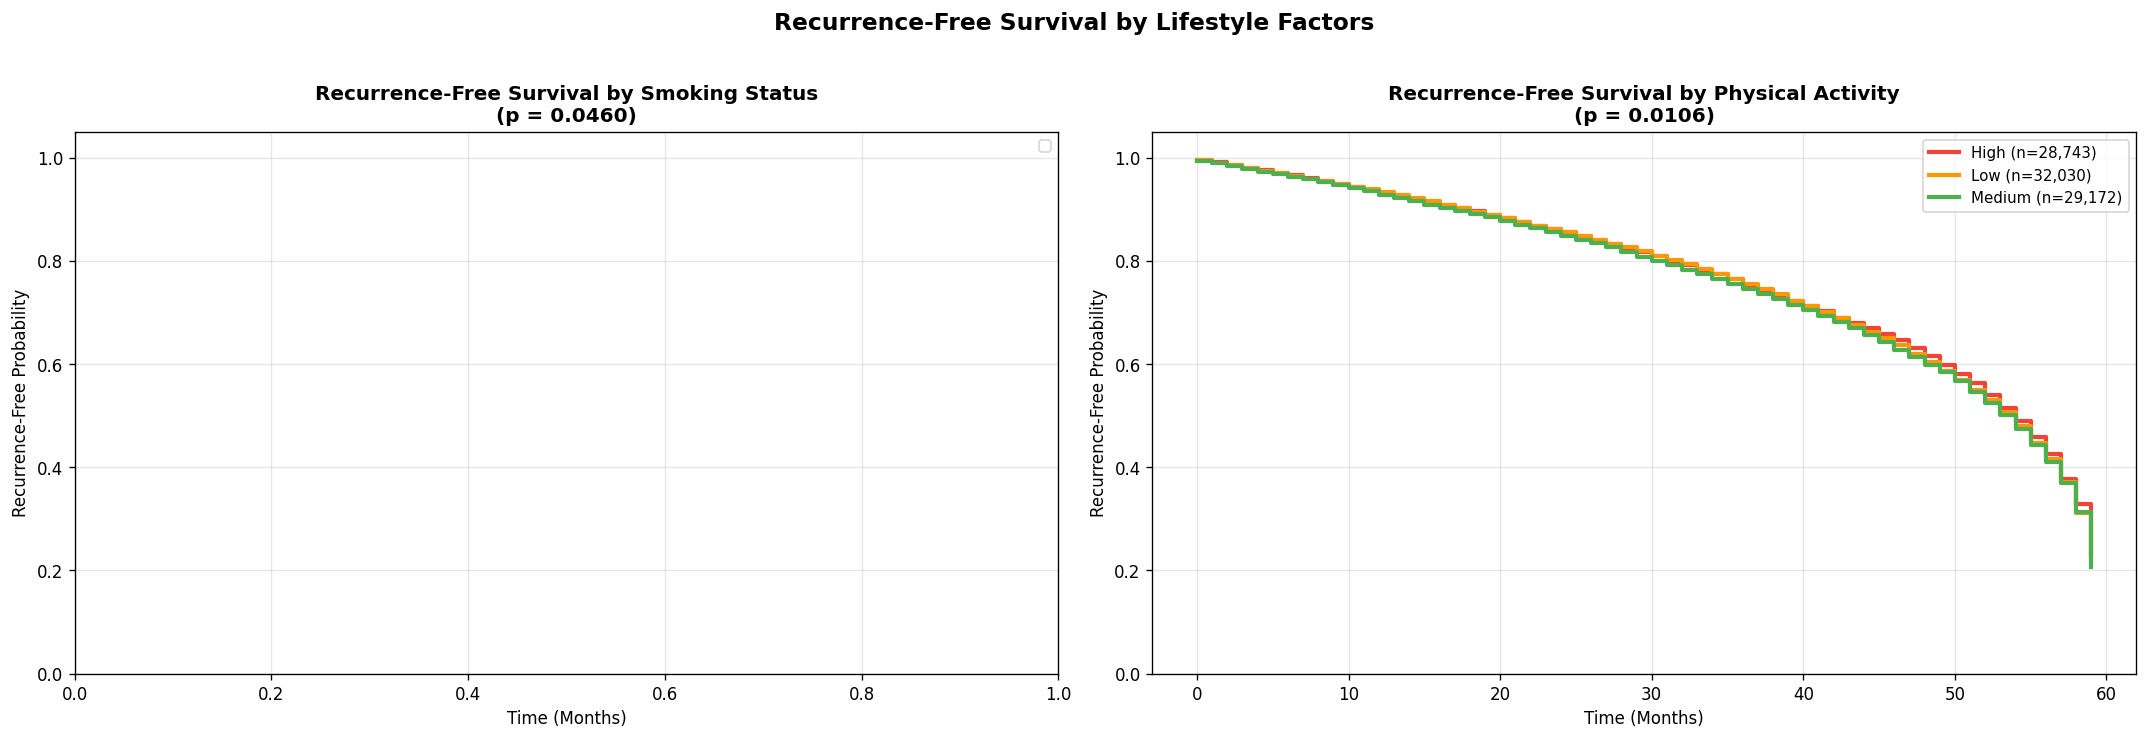

In [13]:
# === KM Curve 7: by Lifestyle (Smoking + Physical Activity) ===
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
kmf = KaplanMeierFitter()

# Smoking
smoke_colors = {'Current Smoker': '#F44336', 'Former Smoker': '#FF9800', 'Never Smoked': '#4CAF50'}
for val, color in smoke_colors.items():
    mask = df['Smoking_Status'] == val
    if mask.sum() > 0:
        kmf.fit(df.loc[mask, 'Duration'],
                event_observed=df.loc[mask, 'Event_Recurrence'],
                label=f'{val} (n={mask.sum():,})')
        kmf.plot_survival_function(ax=axes[0], ci_show=False, color=color, linewidth=2.5)

lr_sm = multivariate_logrank_test(df['Duration'], df['Smoking_Status'], df['Event_Recurrence'])
axes[0].set_title(f'Recurrence-Free Survival by Smoking Status\n(p = {lr_sm.p_value:.4f})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (Months)'); axes[0].set_ylabel('Recurrence-Free Probability')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1.05)

# Physical Activity
pa_groups = df['Physical_Activity_Level'].unique()
pa_colors_list = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
for val, color in zip(sorted(pa_groups), pa_colors_list):
    mask = df['Physical_Activity_Level'] == val
    kmf.fit(df.loc[mask, 'Duration'],
            event_observed=df.loc[mask, 'Event_Recurrence'],
            label=f'{val} (n={mask.sum():,})')
    kmf.plot_survival_function(ax=axes[1], ci_show=False, color=color, linewidth=2.5)

lr_pa = multivariate_logrank_test(df['Duration'], df['Physical_Activity_Level'], df['Event_Recurrence'])
axes[1].set_title(f'Recurrence-Free Survival by Physical Activity\n(p = {lr_pa.p_value:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (Months)'); axes[1].set_ylabel('Recurrence-Free Probability')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1.05)

plt.suptitle('Recurrence-Free Survival by Lifestyle Factors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nb3_fig8_km_lifestyle.png', bbox_inches='tight')
plt.show()

In [14]:
# === Prepare data for Cox model ===
from sklearn.preprocessing import LabelEncoder

cox_features = [
    'Age', 'BMI', 'Stage_Num',
    'Gender', 'Socioeconomic_Status',
    'Smoking_Status', 'Physical_Activity_Level',
    'Alcohol_Consumption', 'Diet_Type',
    'Red_Meat_Consumption', 'Fiber_Consumption',
    'Family_History', 'Previous_Cancer_History',
    'Chemotherapy_Received', 'Radiotherapy_Received', 'Surgery_Received',
    'Insurance_Coverage', 'Treatment_Access',
    'Follow_Up_Adherence', 'Tumor_Aggressiveness',
    'Time_to_Diagnosis'
]

cox_df = df[cox_features + ['Duration', 'Event_Recurrence']].copy()

# Encode categoricals
for col in cox_df.select_dtypes('object').columns:
    cox_df[col] = LabelEncoder().fit_transform(cox_df[col].astype(str))

# Normalise continuous features
for col in ['Age', 'BMI']:
    cox_df[col] = (cox_df[col] - cox_df[col].mean()) / cox_df[col].std()

print(f'Cox model features: {len(cox_features)}')
print('Sample:')
cox_df.head(3)

Cox model features: 21
Sample:


,Age,BMI,Stage_Num,Gender,Socioeconomic_Status,Smoking_Status,Physical_Activity_Level,Alcohol_Consumption,Diet_Type,Red_Meat_Consumption,...,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Insurance_Coverage,Treatment_Access,Follow_Up_Adherence,Tumor_Aggressiveness,Time_to_Diagnosis,Duration,Event_Recurrence
0,0.706544,0.265037,3,1,2,2,1,1,1,1,...,1,0,0,1,0,0,2,0,16,0
1,-1.096726,-1.357018,1,0,0,1,0,2,0,1,...,0,1,1,1,0,1,1,1,28,0
2,0.896362,0.042838,3,0,1,1,2,0,1,1,...,0,1,1,1,1,0,0,1,26,0


In [15]:
# === Fit Cox Model ===
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col='Duration', event_col='Event_Recurrence')

print('=== Cox Proportional Hazards Model — Summary ===')
cph.print_summary()

=== Cox Proportional Hazards Model — Summary ===


<lifelines.CoxPHFitter: fitted with 89945 total observations, 62975 right-censored observations>
             duration col = 'Duration'
                event col = 'Event_Recurrence'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 89945
number of events observed = 26970
   partial log-likelihood = -281547.06
         time fit was run = 2026-05-29 10:30:43 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Age                      0.00      1.00      0.01           -0.01            0.02                0.99                1.02
BMI                      0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Stage_Num               -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
Gender                   0.02      1.02      0.01           -0.00            0.04                1.00                1.04
Socioeconomic_Status     0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Smoking_Status          -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
Physical_Activity_Level  0.02      1.02      0.01            0.00            0.03                1.00                1.03
Alcohol_Consumption      0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Diet_Type                0.01      1.01      0.01           -0.00            0.02                1.00                1.02
Red_Meat_Consumption     0.00      1.00      0.01           -0.01            0.02                0.99                1.02
Fiber_Consumption        0.01      1.01      0.01           -0.01            0.02                0.99                1.02
Family_History          -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
Previous_Cancer_History  0.00      1.00      0.01           -0.02            0.03                0.98                1.03
Chemotherapy_Received   -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Radiotherapy_Received    0.01      1.01      0.01           -0.01            0.03                0.99                1.03
Surgery_Received         0.01      1.01      0.01           -0.01            0.03                0.99                1.03
Insurance_Coverage      -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
Treatment_Access         0.01      1.01      0.01           -0.01            0.03                0.99                1.03
Follow_Up_Adherence     -0.02      0.98      0.01           -0.04            0.00                0.96                1.00
Tumor_Aggressiveness    -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Time_to_Diagnosis       -0.01      0.99      0.01           -0.03            0.02                0.97                1.02

                         cmp to     z    p  -log2(p)
covariate                                           
Age                        0.00  0.39 0.69      0.53
BMI                        0.00  0.68 0.50      1.00
Stage_Num                  0.00 -0.21 0.84      0.26
Gender                     0.00  1.90 0.06      4.13
Socioeconomic_Status       0.00  0.10 0.92      0.11
Smoking_Status             0.00 -1.55 0.12      3.04
Physical_Activity_Level    0.00  2.32 0.02      5.61
Alcohol_Consumption        0.00  0.51 0.61      0.71
Diet_Type                  0.00  1.25 0.21      2.23
Red_Meat_Consumption       0.00  0.32 0.75      0.42
Fiber_Consumption          0.00  1.03 0.30      1.71
Family_History             0.00 -0.57 0.57      0.81
Prev

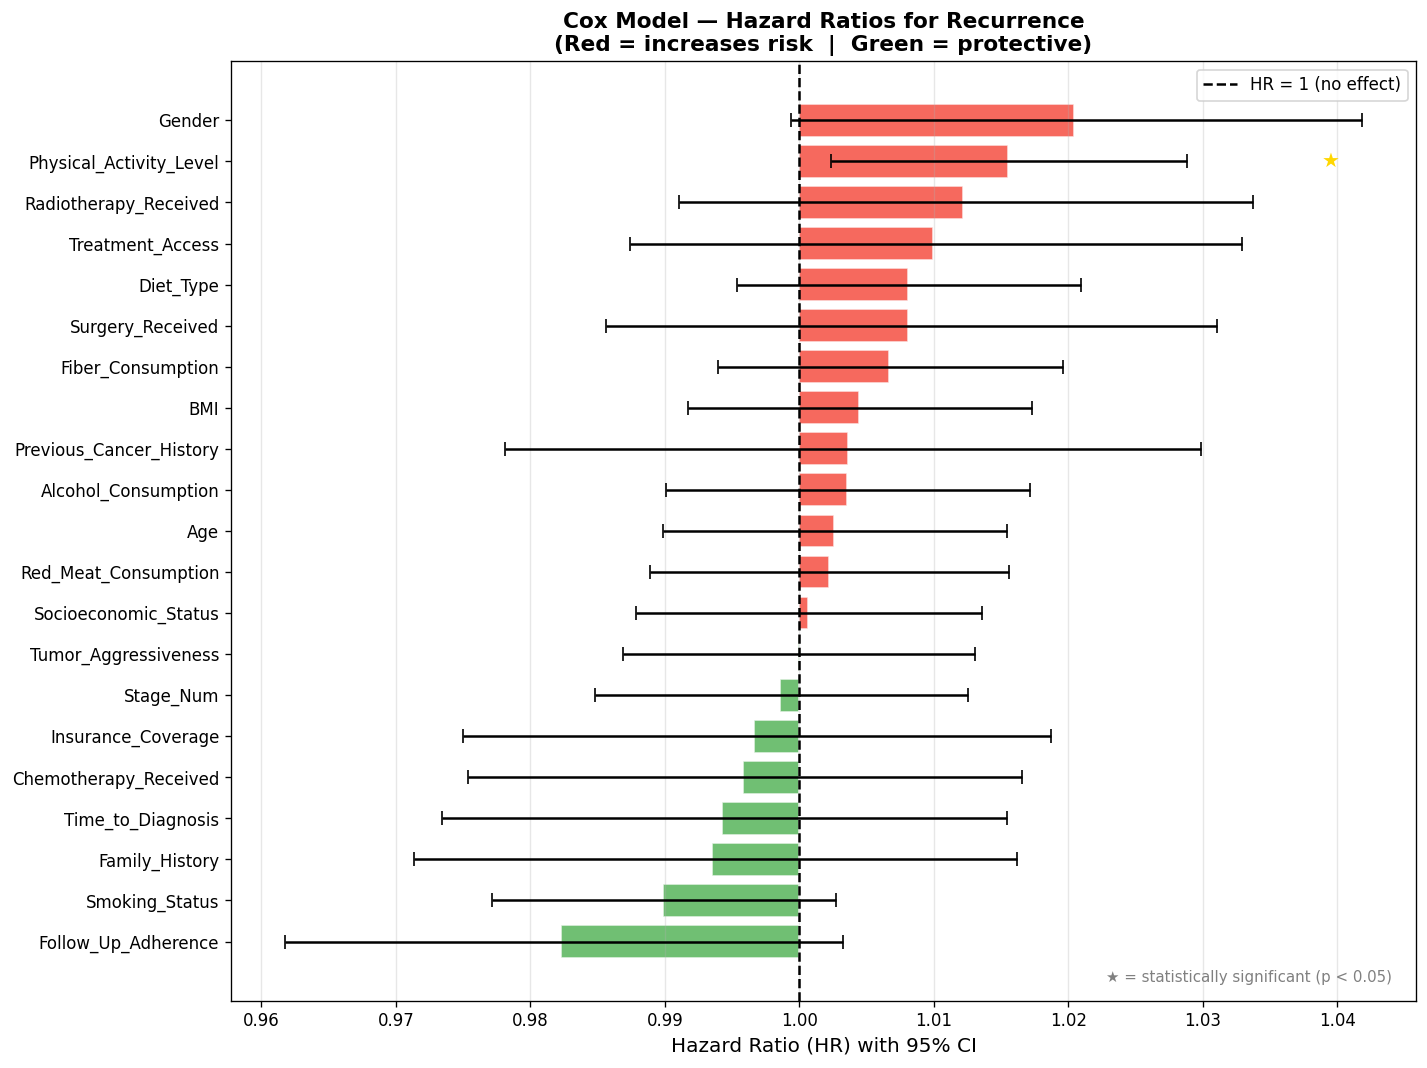

In [16]:
# === Forest Plot — Hazard Ratios ===
summary = cph.summary.copy()
summary = summary.sort_values('exp(coef)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

colors = ['#F44336' if v > 1 else '#4CAF50' for v in summary['exp(coef)']]
y_pos = range(len(summary))

ax.barh(y_pos, summary['exp(coef)'] - 1,
        left=1, color=colors, alpha=0.8, edgecolor='white')
ax.errorbar(summary['exp(coef)'], y_pos,
            xerr=[summary['exp(coef)'] - summary['exp(coef) lower 95%'],
                  summary['exp(coef) upper 95%'] - summary['exp(coef)']],
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(summary.index, fontsize=10)
ax.axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='HR = 1 (no effect)')
ax.set_xlabel('Hazard Ratio (HR) with 95% CI', fontsize=12)
ax.set_title('Cox Model — Hazard Ratios for Recurrence\n(Red = increases risk  |  Green = protective)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Mark significant ones
sig_mask = summary['p'] < 0.05
for idx, (i, row) in enumerate(summary.iterrows()):
    if row['p'] < 0.05:
        ax.text(summary['exp(coef) upper 95%'].iloc[list(summary.index).index(i)] + 0.01,
                list(y_pos)[list(summary.index).index(i)],
                '★', color='gold', fontsize=12, va='center')

ax.text(0.98, 0.02, '★ = statistically significant (p < 0.05)',
        transform=ax.transAxes, fontsize=9, ha='right', color='gray')

plt.tight_layout()
plt.savefig('nb3_fig9_cox_forest_plot.png', bbox_inches='tight')
plt.show()

In [17]:
# === Median Recurrence-Free Time: Full Subgroup Table ===
subgroup_cols = [
    ('Stage_at_Diagnosis', STAGE_ORDER),
    ('Tumor_Aggressiveness', ['Low', 'Medium', 'High']),
    ('Chemotherapy_Received', ['Yes', 'No']),
    ('Surgery_Received', ['Yes', 'No']),
    ('Follow_Up_Adherence', ['Good', 'Poor']),
    ('Treatment_Access', ['Good', 'Limited']),
    ('Socioeconomic_Status', ['Low', 'Middle', 'High']),
    ('Insurance_Coverage', sorted(df['Insurance_Coverage'].unique())),
    ('Time_to_Diagnosis', ['Timely', 'Delayed']),
    ('Smoking_Status', sorted(df['Smoking_Status'].unique())),
]

rows = []
kmf = KaplanMeierFitter()

for col, groups in subgroup_cols:
    for grp in groups:
        mask = df[col] == grp
        if mask.sum() < 10:
            continue
        kmf.fit(df.loc[mask, 'Duration'], event_observed=df.loc[mask, 'Event_Recurrence'])
        rows.append({
            'Factor': col,
            'Group': grp,
            'N': int(mask.sum()),
            'Events (Recurrence)': int(df.loc[mask, 'Event_Recurrence'].sum()),
            'Recurrence Rate (%)': round(df.loc[mask, 'Event_Recurrence'].mean() * 100, 1),
            'Median RFS (months)': round(kmf.median_survival_time_, 1),
            '12-month RFS (%)': round(kmf.predict(12) * 100, 1),
            '24-month RFS (%)': round(kmf.predict(24) * 100, 1),
            '48-month RFS (%)': round(kmf.predict(48) * 100, 1),
        })

subgroup_table = pd.DataFrame(rows)
print('=== Subgroup Survival Summary Table ===')
subgroup_table

=== Subgroup Survival Summary Table ===


,Factor,Group,N,Events (Recurrence),Recurrence Rate (%),Median RFS (months),12-month RFS (%),24-month RFS (%),48-month RFS (%)
0,Stage_at_Diagnosis,I,22594,6762,29.9,54.0,93.2,85.4,60.2
1,Stage_at_Diagnosis,II,26869,7985,29.7,54.0,93.3,85.7,61.2
2,Stage_at_Diagnosis,III,22412,6797,30.3,54.0,92.9,85.1,60.5
3,Stage_at_Diagnosis,IV,18070,5426,30.0,54.0,93.0,85.1,60.5
4,Tumor_Aggressiveness,Low,31240,9382,30.0,54.0,93.2,85.6,60.5
5,Tumor_Aggressiveness,Medium,29153,8786,30.1,54.0,93.1,85.1,60.7
6,Tumor_Aggressiveness,High,29552,8802,29.8,54.0,93.0,85.3,60.8
7,Chemotherapy_Received,Yes,45067,13508,30.0,54.0,93.2,85.5,60.7
8,Chemotherapy_Received,No,44878,13462,30.0,54.0,93.0,85.2,60.5
9,Surgery_Received,Yes,62879,18854,30.0,54.0,93.1,85.3,60.7


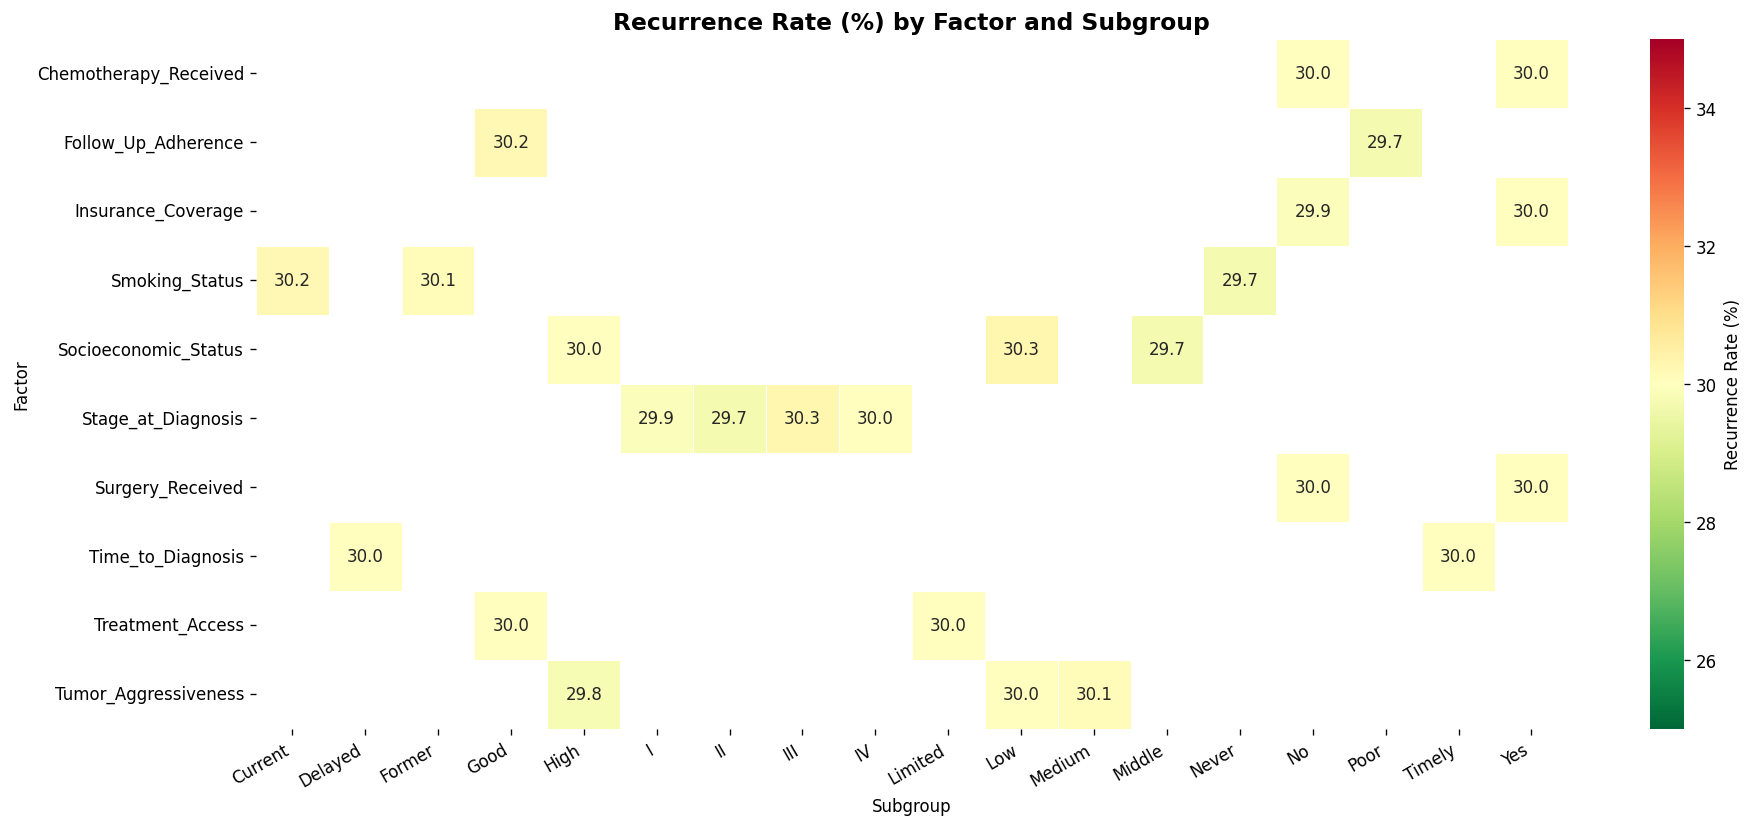

In [18]:
# === Median RFS Heatmap ===
pivot_data = subgroup_table.pivot_table(
    index='Factor', columns='Group',
    values='Recurrence Rate (%)', aggfunc='mean'
)

plt.figure(figsize=(16, 7))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Recurrence Rate (%)'},
            vmin=25, vmax=35)
plt.title('Recurrence Rate (%) by Factor and Subgroup', fontsize=14, fontweight='bold')
plt.xlabel('Subgroup'); plt.ylabel('Factor')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('nb3_fig10_recurrence_heatmap.png', bbox_inches='tight')
plt.show()

In [19]:
# === Statistical significance of each factor on recurrence ===
test_cols = [
    'Stage_at_Diagnosis', 'Tumor_Aggressiveness',
    'Chemotherapy_Received', 'Radiotherapy_Received', 'Surgery_Received',
    'Follow_Up_Adherence', 'Treatment_Access', 'Insurance_Coverage',
    'Socioeconomic_Status', 'Time_to_Diagnosis',
    'Smoking_Status', 'Physical_Activity_Level',
    'Diet_Type', 'Red_Meat_Consumption', 'Fiber_Consumption',
    'Family_History', 'Previous_Cancer_History',
    'Gender', 'Urban_or_Rural'
]

logrank_results = []
for col in test_cols:
    try:
        result = multivariate_logrank_test(
            df['Duration'], df[col], df['Event_Recurrence']
        )
        logrank_results.append({
            'Factor': col,
            'Test Statistic': round(result.test_statistic, 4),
            'p-value': round(result.p_value, 6),
            'Significant (p<0.05)': '✅ Yes' if result.p_value < 0.05 else '❌ No'
        })
    except Exception as e:
        pass

lr_df = pd.DataFrame(logrank_results).sort_values('p-value')
print('=== Log-Rank Test Results — Impact on Recurrence-Free Survival ===')
lr_df

=== Log-Rank Test Results — Impact on Recurrence-Free Survival ===


,Factor,Test Statistic,p-value,Significant (p<0.05)
11,Physical_Activity_Level,9.0863,0.010640,✅ Yes
17,Gender,4.7432,0.029414,✅ Yes
10,Smoking_Status,6.1585,0.045994,✅ Yes
5,Follow_Up_Adherence,3.6701,0.055397,❌ No
12,Diet_Type,5.4183,0.066592,❌ No
0,Stage_at_Diagnosis,5.7322,0.125392,❌ No
3,Radiotherapy_Received,1.7556,0.185173,❌ No
7,Insurance_Coverage,1.2994,0.254332,❌ No
14,Fiber_Consumption,2.4309,0.296570,❌ No
6,Treatment_Access,1.0357,0.308829,❌ No


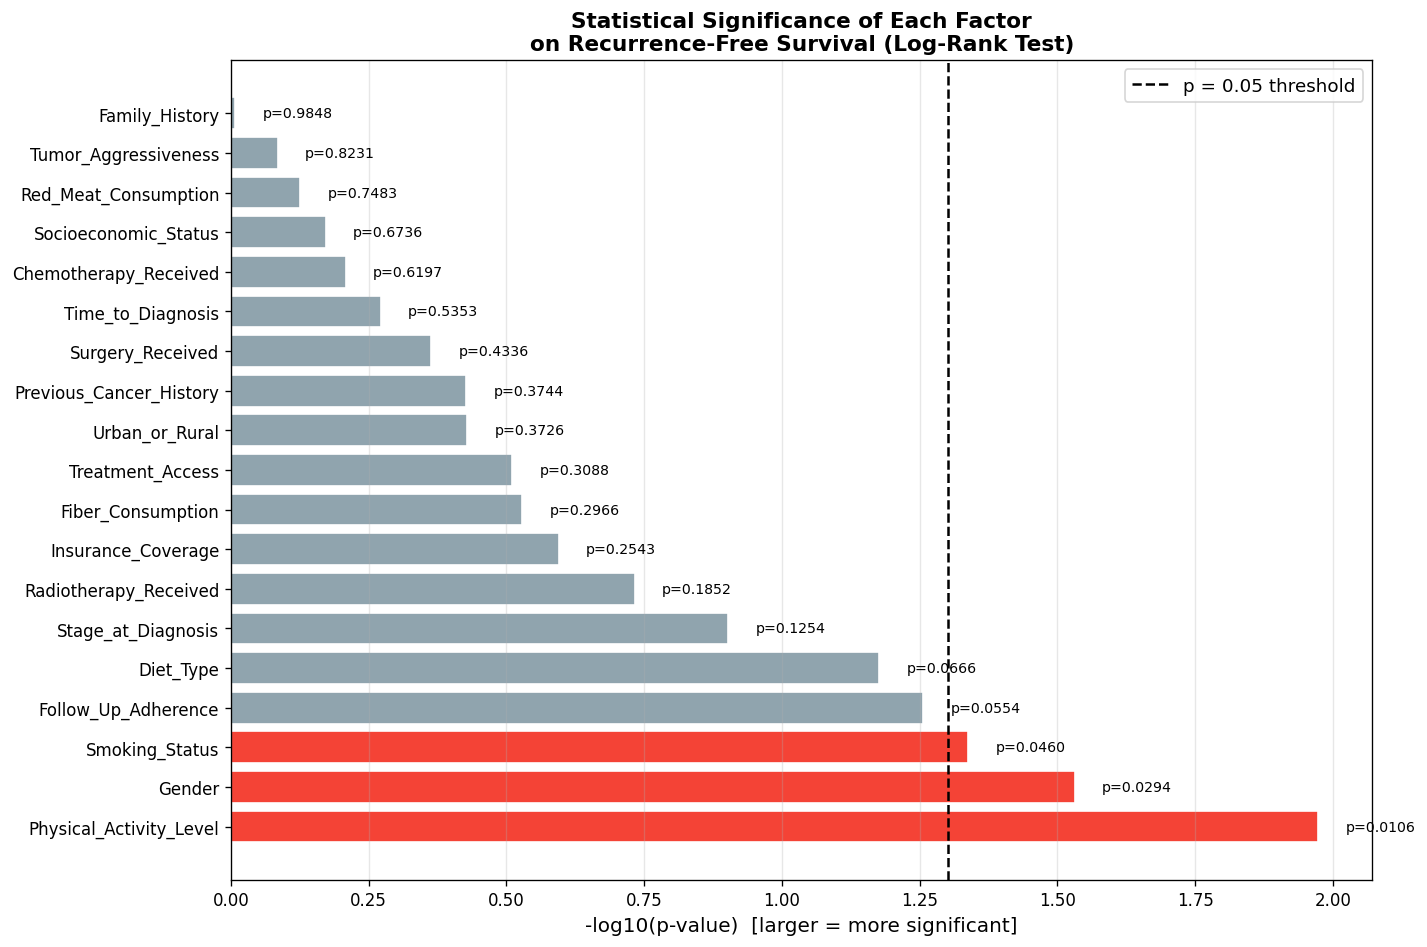

In [20]:
# === Visualise p-values ===
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#F44336' if p < 0.05 else '#90A4AE' for p in lr_df['p-value']]
bars = ax.barh(lr_df['Factor'], -np.log10(lr_df['p-value'] + 1e-10),
               color=colors, edgecolor='white')
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.5,
           label='p = 0.05 threshold')

ax.set_xlabel('-log10(p-value)  [larger = more significant]', fontsize=12)
ax.set_title('Statistical Significance of Each Factor\non Recurrence-Free Survival (Log-Rank Test)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)

# Labels
for bar, p in zip(bars, lr_df['p-value']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'p={p:.4f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('nb3_fig11_logrank_significance.png', bbox_inches='tight')
plt.show()

In [21]:
# === Which treatment combination has best outcomes? ===
df['Treatment_Combo'] = (
    df['Chemotherapy_Received'].apply(lambda x: 'C' if x == 'Yes' else '') +
    df['Radiotherapy_Received'].apply(lambda x: 'R' if x == 'Yes' else '') +
    df['Surgery_Received'].apply(lambda x: 'S' if x == 'Yes' else '')
)
df['Treatment_Combo'] = df['Treatment_Combo'].replace('', 'None')

combo_summary = df.groupby('Treatment_Combo').agg(
    N=('Event_Recurrence', 'count'),
    Recurrence_Rate=('Event_Recurrence', lambda x: round(x.mean() * 100, 1)),
    Mortality_Rate=('Event_Deceased', lambda x: round(x.mean() * 100, 1))
).sort_values('Recurrence_Rate').reset_index()

print('=== Treatment Combination Outcomes ===')
print('C=Chemo, R=Radio, S=Surgery')
print(combo_summary.to_string(index=False))

=== Treatment Combination Outcomes ===
C=Chemo, R=Radio, S=Surgery
Treatment_Combo     N  Recurrence_Rate  Mortality_Rate
              S 18792             29.7            24.5
             CR  5385             29.8            26.5
             CS 18956             29.9            24.9
              C  8146             29.9            25.3
              R  5477             29.9            25.3
            CRS 12580             30.3            25.2
           None  8058             30.3            25.3
             RS 12551             30.3            25.4


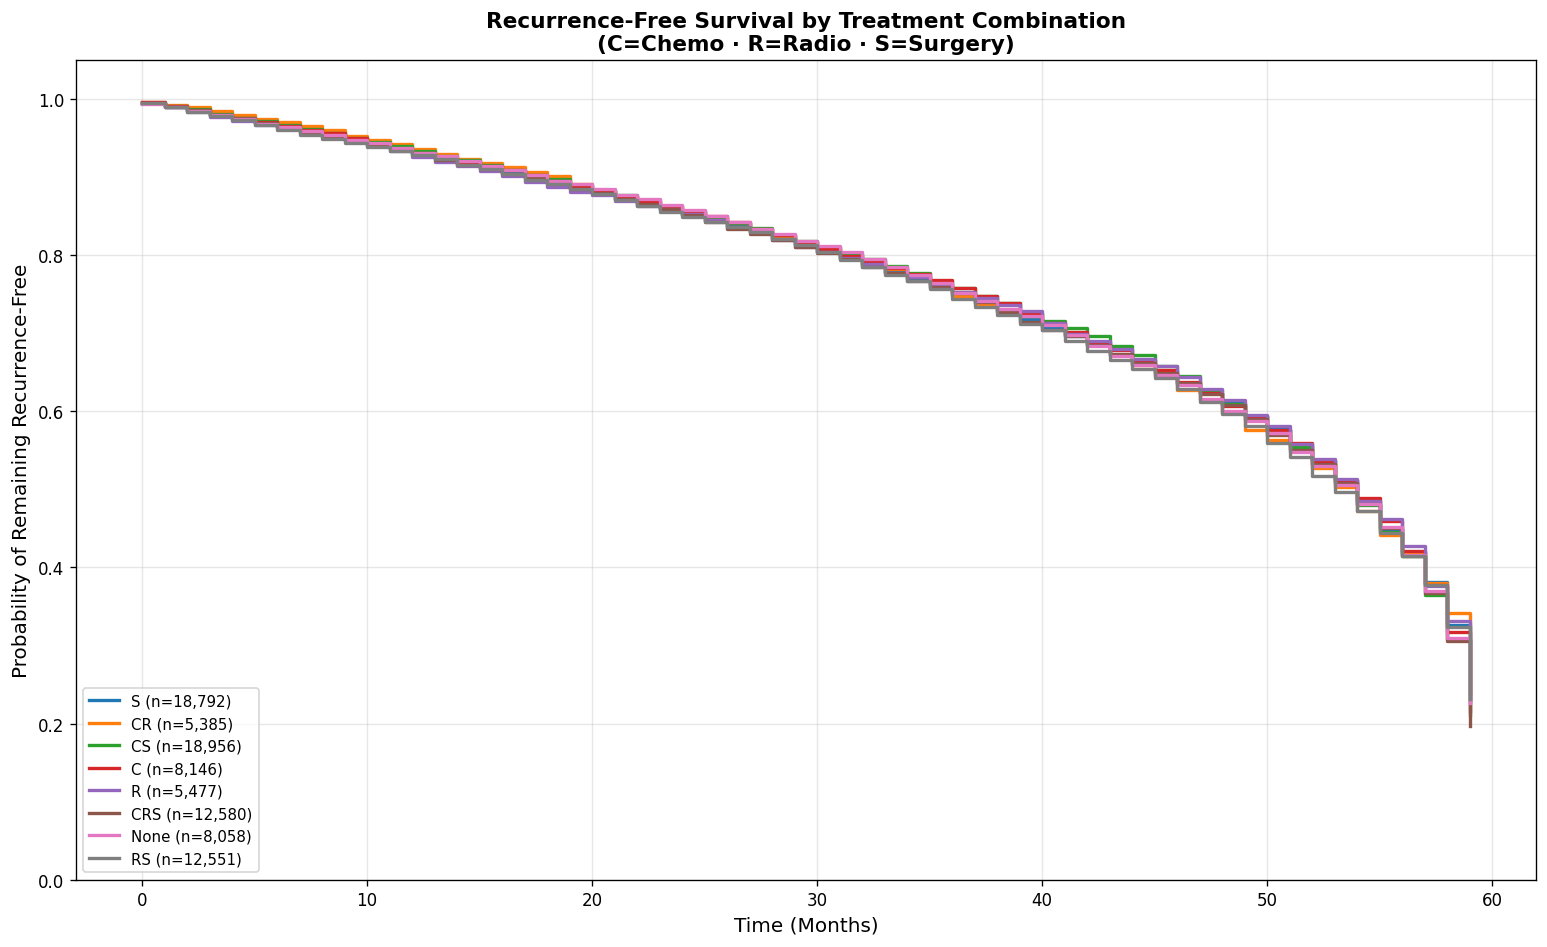

In [22]:
# === KM Curves by Treatment Combination ===
fig, ax = plt.subplots(figsize=(13, 8))
kmf = KaplanMeierFitter()

top_combos = combo_summary[combo_summary['N'] >= 1000]['Treatment_Combo'].tolist()
palette = plt.cm.tab10.colors

for i, combo in enumerate(top_combos):
    mask = df['Treatment_Combo'] == combo
    n = mask.sum()
    kmf.fit(df.loc[mask, 'Duration'],
            event_observed=df.loc[mask, 'Event_Recurrence'],
            label=f'{combo if combo else "None"} (n={n:,})')
    kmf.plot_survival_function(ax=ax, ci_show=False,
                                color=palette[i % len(palette)], linewidth=2)

ax.set_title('Recurrence-Free Survival by Treatment Combination\n(C=Chemo · R=Radio · S=Surgery)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time (Months)', fontsize=12)
ax.set_ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('nb3_fig12_km_treatment_combo.png', bbox_inches='tight')
plt.show()

In [23]:
kmf_all = KaplanMeierFitter()
kmf_all.fit(df['Duration'], event_observed=df['Event_Recurrence'])

sig_factors = lr_df[lr_df['p-value'] < 0.05]['Factor'].tolist()
best_combo = combo_summary.iloc[0]['Treatment_Combo']
best_combo_rec = combo_summary.iloc[0]['Recurrence_Rate']
worst_combo = combo_summary.iloc[-1]['Treatment_Combo']
worst_combo_rec = combo_summary.iloc[-1]['Recurrence_Rate']

print('=' * 65)
print('  NOTEBOOK 3 — SURVIVAL ANALYSIS: KEY FINDINGS')
print('=' * 65)
print(f'\n  Dataset       : {len(df):,} CRC patients')
print(f'  Follow-up     : 0–59 months')
print(f'  Overall recurrence rate  : {df["Event_Recurrence"].mean()*100:.1f}%')
print(f'  Median recurrence-free survival : {kmf_all.median_survival_time_:.0f} months')
print(f'  12-month RFS  : {kmf_all.predict(12)*100:.1f}%')
print(f'  24-month RFS  : {kmf_all.predict(24)*100:.1f}%')
print(f'  48-month RFS  : {kmf_all.predict(48)*100:.1f}%')

print(f'\n  Statistically Significant Factors (Log-Rank p < 0.05):')
for f in sig_factors:
    print(f'    ✅ {f}')

print(f'\n  Best treatment combination  : {best_combo} ({best_combo_rec}% recurrence)')
print(f'  Worst treatment combination : {worst_combo} ({worst_combo_rec}% recurrence)')

print(f'\n  Cox Model Top Risk Factors (HR > 1 = increases recurrence risk):')
top_cox = cph.summary.sort_values('exp(coef)', ascending=False).head(5)
for feat, row in top_cox.iterrows():
    print(f'    {feat}: HR = {row["exp(coef)"]:.3f} (p = {row["p"]:.4f})')

print()
print('  ✅ Full 3-step Clinical Pipeline Complete:')
print('     NB1: CRC Risk Detection → NB2: Stage Classification → NB3: Survival Analysis')
print('=' * 65)

  NOTEBOOK 3 — SURVIVAL ANALYSIS: KEY FINDINGS

  Dataset       : 89,945 CRC patients
  Follow-up     : 0–59 months
  Overall recurrence rate  : 30.0%
  Median recurrence-free survival : 54 months
  12-month RFS  : 93.1%
  24-month RFS  : 85.4%
  48-month RFS  : 60.6%

  Statistically Significant Factors (Log-Rank p < 0.05):
    ✅ Physical_Activity_Level
    ✅ Gender
    ✅ Smoking_Status

  Best treatment combination  : S (29.7% recurrence)
  Worst treatment combination : RS (30.3% recurrence)

  Cox Model Top Risk Factors (HR > 1 = increases recurrence risk):
    Gender: HR = 1.020 (p = 0.0570)
    Physical_Activity_Level: HR = 1.016 (p = 0.0205)
    Radiotherapy_Received: HR = 1.012 (p = 0.2619)
    Treatment_Access: HR = 1.010 (p = 0.3911)
    Diet_Type: HR = 1.008 (p = 0.2128)

  ✅ Full 3-step Clinical Pipeline Complete:
     NB1: CRC Risk Detection → NB2: Stage Classification → NB3: Survival Analysis


In [24]:
# ============================================================
# SAVE NB3 OUTPUTS
# ============================================================
import os
os.makedirs('saved_models', exist_ok=True)

# Save subgroup summary table
subgroup_table.to_csv('saved_models/nb3_subgroup_summary.csv', index=False)

# Save log-rank results
lr_df.to_csv('saved_models/nb3_logrank_results.csv', index=False)

# Save treatment combo summary
combo_summary.to_csv('saved_models/nb3_treatment_combos.csv', index=False)

# Save Cox model (useful if Flask needs hazard ratios)
import pickle
with open('saved_models/nb3_cox_model.pkl', 'wb') as f:
    pickle.dump(cph, f)

print('✅ NB3 outputs saved')
print('   saved_models/nb3_subgroup_summary.csv')
print('   saved_models/nb3_logrank_results.csv')
print('   saved_models/nb3_treatment_combos.csv')
print('   saved_models/nb3_cox_model.pkl')

✅ NB3 outputs saved
   saved_models/nb3_subgroup_summary.csv
   saved_models/nb3_logrank_results.csv
   saved_models/nb3_treatment_combos.csv
   saved_models/nb3_cox_model.pkl
